## 1. What this notebook computes

After *quantisation* the 16 components of the field dirac16complex are no longer
numbers but **operators** $\Psi_A$ ($A = 1, \dots, 16$), and the Revision record
fixes how they combine: on a slice of constant time $x_4$,
$$\{\Psi_A(x), \Psi^\dagger_C(y)\} = B_{AC}\,\delta^7(x - y)/\cos z,\qquad
B = -iC\gamma^{(x4)} ,$$
the **canonical anticommutator**. A charge conjugation of the quantised field must
turn $\Psi$ into a new field $\Psi' = M\Psi^{\dagger T}$ (built from the adjoint
operators, arranged as a column, times a constant matrix $M$) that obeys **the
same** rule; otherwise $\Psi'$ is not a field of the same quantum theory. This
notebook

1. derives the condition $MB^TM^\dagger = B$ and shows: it holds for
   $M = \Gamma$, it fails for $M = 1$ (that choice gives $-B$), and among all
   matrices $\cos t\,1 + \sin t\,\Gamma$ it holds only for $\pm\Gamma$
   (record check quantum_charge_conjugation_unitary_type);
2. builds the 16 field operators explicitly, as $65536 \times 65536$ operators on
   the states of 16 fermion modes, and measures all 256 anticommutators of
   $\Psi$, of $\Gamma\Psi^{\dagger T}$ and of $\Psi^{\dagger T}$;
3. shows that the valid conjugation counts the *empty* modes: its charge is
   $16 - Q$, the charge reversed up to a constant (particles become holes);
4. proves with sympy that the conjugated field obeys the field equation with the
   **mass reversed**, and that nevertheless the one-particle spectra of the masses
   $+m$ and $-m$ are identical; it reproduces the eight samples of the Revision
   pairing record (frequencies, dimensions, Krein inertia) and scans the
   extra-time momentum into the region of growing modes.

Six teaching plots.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 21c (The conjugation of the quantised field: M B^T M^dagger = B) is the file
`Revision/textbook/notebooks/21c_quantum_conjugation.ipynb` of the repository
Dirac_claude. It derives the condition M B^T M^dagger = B that a conjugation Psi to M
Psi^dagger T must satisfy to preserve the canonical anticommutator of the quantised field
dirac16complex (B = -i C gamma^(x4), the Krein matrix), finds that it holds for M = Gamma
and fails for M = 1 (and, among the matrices cos t + sin t Gamma, only for Gamma),
verifies this with explicit fermion operators on the 65536 states of 16 modes
(Jordan-Wigner construction in the positive representation of the Revision record), shows
that the valid conjugation turns the charge Q into 16 - Q (particles into holes), proves
with sympy that it maps the one-particle Hamiltonian of mass m to that of mass -m, and
reproduces the one-particle samples of the Revision pairing record: equal spectra for +m
and -m, Krein inertia (4,4) at real frequencies, Krein-neutral growing modes at large
extra-time momentum. Six teaching plots. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 21c_quantum_conjugation.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 30 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 21c_quantum_conjugation.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
21c_quantum_conjugation.ipynb` (in the same folder, without running the cells again) to
read the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/21c.captions.json`
- `Revision/textbook/figures/21c_1_krein_matrix.png`
- `Revision/textbook/figures/21c_2_which_conjugation.png`
- `Revision/textbook/figures/21c_3_operator_anticommutators.png`
- `Revision/textbook/figures/21c_4_charge_of_states.png`
- `Revision/textbook/figures/21c_5_dispersion_pm_mass.png`
- `Revision/textbook/figures/21c_6_krein_inertia_scan.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS the six figure files of notebook 21c exist
    ALL 16 CHECKS PASSED (notebook 21c)

and the notebook must show 6 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/21c_quantum_conjugation.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file in the folder `Revision/algebra`, `Revision/theory`,
  `Revision/pairing` or `Revision/lead_checks`: the notebook was opened outside the
  repository, or the repository is incomplete; clone the repository again and open the
  notebook from its folder `Revision/textbook/notebooks`.
- "MemoryError" in the cells of section 7: the operators act on columns of 65536 complex
  numbers (1 MB each); close other programs and run the notebook again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 21c (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 21c (The conjugation of the quantised field: M B^T M^dagger = B) is the file
# Revision/textbook/notebooks/21c_quantum_conjugation.ipynb of the repository
# Dirac_claude. It derives the condition M B^T M^dagger = B that a conjugation Psi to M
# Psi^dagger T must satisfy to preserve the canonical anticommutator of the quantised
# field dirac16complex (B = -i C gamma^(x4), the Krein matrix), finds that it holds for M
# = Gamma and fails for M = 1 (and, among the matrices cos t + sin t Gamma, only for
# Gamma), verifies this with explicit fermion operators on the 65536 states of 16 modes
# (Jordan-Wigner construction in the positive representation of the Revision record),
# shows that the valid conjugation turns the charge Q into 16 - Q (particles into holes),
# proves with sympy that it maps the one-particle Hamiltonian of mass m to that of mass
# -m, and reproduces the one-particle samples of the Revision pairing record: equal
# spectra for +m and -m, Krein inertia (4,4) at real frequencies, Krein-neutral growing
# modes at large extra-time momentum. Six teaching plots. It needs a computer with
# Windows 11, macOS or Linux, an internet connection for the installation, the program
# Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
# packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
# 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
# nbconvert 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 21c_quantum_conjugation.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 30
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 21c_quantum_conjugation.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 21c_quantum_conjugation.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/21c.captions.json
# - Revision/textbook/figures/21c_1_krein_matrix.png
# - Revision/textbook/figures/21c_2_which_conjugation.png
# - Revision/textbook/figures/21c_3_operator_anticommutators.png
# - Revision/textbook/figures/21c_4_charge_of_states.png
# - Revision/textbook/figures/21c_5_dispersion_pm_mass.png
# - Revision/textbook/figures/21c_6_krein_inertia_scan.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS the six figure files of notebook 21c exist
#     ALL 16 CHECKS PASSED (notebook 21c)
#
# and the notebook must show 6 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/21c_quantum_conjugation.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file in the folder Revision/algebra, Revision/theory,
#   Revision/pairing or Revision/lead_checks: the notebook was opened outside the
#   repository, or the repository is incomplete; clone the repository again and open the
#   notebook from its folder Revision/textbook/notebooks.
# - "MemoryError" in the cells of section 7: the operators act on columns of 65536
#   complex numbers (1 MB each); close other programs and run the notebook again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "21c"  # this notebook: chapter 21, example c


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 21c complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Operator**: a rule that turns one state of a quantum system into another; with
  a basis of the states it is a (large) matrix. Operators need not commute:
  $XY \ne YX$ in general.
- **Anticommutator** $\{X, Y\} = XY + YX$.
- **Fermion modes, occupation**: a fermion mode is either empty (0) or occupied
  (1); 16 modes have $2^{16} = 65536$ states, each a list of 16 zeros and ones.
  The **annihilation operator** $b_j$ empties mode $j$ (and gives zero if it is
  already empty), the **creation operator** $b_j^*$ fills it; they obey
  $\{b_j, b_k^*\} = \delta_{jk}$ and $\{b_j, b_k\} = 0$. The sign rule that makes
  them anticommute is the **Jordan-Wigner** rule: acting on mode $j$ gives the
  factor $(-1)$ to the power of the number of occupied modes before $j$.
- **Hilbert adjoint** $X^*$: the conjugate transpose of the matrix of $X$ in an
  ordinary (positive) inner product.
- **Canonical anticommutator**: the rule $\{\Psi_A, \Psi^\dagger_C\} = B_{AC}$
  (times the delta function) that canonical quantisation of the Lagrangian gives.
  Because $B$ has eight eigenvalues $+1$ and eight $-1$, $\Psi^\dagger$ cannot be
  the Hilbert adjoint of $\Psi$; the Revision record realises it as $\Psi^\dagger
  = b^*B$ (the **positive representation**: $\Psi_A = b_A$, $\Psi^\dagger_C =
  \sum_D b^*_D B_{DC}$).
- **Krein matrix, Krein form**: $B$, and the indefinite form $u^\dagger Bv$;
  **Krein inertia** $(p, n)$ of a space: the numbers of positive and negative
  eigenvalues of the form restricted to it; **Krein-neutral**: the form vanishes
  on the space.
- **Charge operator** $Q = \sum_{A,C}\Psi^\dagger_A B_{AC}\Psi_C$ (the integral
  of the charge density $\Psi^\dagger B\Psi$ for one point).
- **One-particle Hamiltonian** $h_m(k)$: the $16 \times 16$ matrix that gives the
  time evolution $i\,\partial_4 u = h_m(k)u$ of a plane wave $u\,e^{ik\cdot x}$ in
  flat 4+4 space; its eigenvalues are the **frequencies** $\pm w$.
- **Extra-time momentum** $k_5, k_6, k_7$: the momentum along the extra times;
  the **good sector** has $k_5 = k_6 = k_7 = 0$.

## 4. The physical and mathematical situation

**The condition, line by line.** Let $\Psi' = M\Psi^{\dagger T}$, that is
$\Psi'_A = \sum_B M_{AB}\Psi^\dagger_B$, with a constant matrix $M$. Its adjoint
is $\Psi'^\dagger_C = \sum_D M^*_{CD}\Psi_D$ (the adjoint of a product of a number
and an operator conjugates the number, and the adjoint of $\Psi^\dagger$ is
$\Psi$).

1. $\{\Psi'_A, \Psi'^\dagger_C\} = \sum_{B,D}M_{AB}M^*_{CD}\{\Psi^\dagger_B,
   \Psi_D\}$, because the anticommutator is linear in each slot.
2. $\{\Psi^\dagger_B, \Psi_D\} = \{\Psi_D, \Psi^\dagger_B\} = B_{DB} =
   (B^T)_{BD}$.
3. Hence $\{\Psi'_A, \Psi'^\dagger_C\} = \sum_{B,D}M_{AB}(B^T)_{BD}(M^\dagger)_{DC}
   = (MB^TM^\dagger)_{AC}$.
4. So $\Psi'$ obeys the canonical rule if and only if
   $$MB^TM^\dagger = B .$$

$B$ is Hermitian and purely imaginary, so $B^T = (B^\dagger)^* = B^* = -B$, and the
condition reads $MBM^\dagger = -B$. For $M = \Gamma$: $\Gamma B\Gamma =
-iC\Gamma\gamma^{(x4)}\Gamma = +iC\gamma^{(x4)} = -B$ (because $\Gamma$ commutes
with $C$ and anticommutes with $\gamma^{(x4)}$), so the condition **holds**. For
$M = 1$: $B = -B$ is **false**.

**Which mass?** A conjugation must also map solutions of the field equation to
solutions. The classical analysis of the charge-conjugation matrices shows that
the only constant matrices doing so are the multiples of $1$ (same mass) and of
$\Gamma$ (mass reversed). So for the quantised field the only conjugation that
keeps the canonical anticommutator is $\Psi \to \Gamma\Psi^{\dagger T}$ (times a
phase), and it **reverses the mass**. Section 9 checks this directly on the
one-particle Hamiltonian.

## 5. The gammas and the Krein matrix B

The next cell reads the eight gamma matrices of the Revision record, checks that
they are eight real $16 \times 16$ matrices with the Clifford relation of
signature (4,4), builds $C$, the chirality $\Gamma$ and $B = -iC\gamma^{(x4)}$,
and reads the Revision records used below.

In [2]:
import numpy as np  # numbers, arrays, matrices
import sympy as sp  # exact algebra

fixture = json.loads(repository_file("Revision/algebra/gammas.json")
                     .read_text(encoding="utf-8"))
COORDS = fixture["coordinates"]  # "x1", ..., "x8"
ETA = fixture["eta"]
gamma = [np.array(mat, dtype=np.int64) for mat in fixture["gamma"]]  # x1 .. x8
I16 = np.eye(16, dtype=np.int64)
check(len(gamma) == 8
      and all(g.shape == (16, 16) and set(np.unique(g)) <= {-1, 0, 1} for g in gamma)
      and all(np.array_equal(gamma[a] @ gamma[b] + gamma[b] @ gamma[a],
                             2 * (ETA[a] if a == b else 0) * I16)
              for a in range(8) for b in range(8)),
      "eight real 16 x 16 gamma matrices with the Clifford relation, signature (4,4)")
C = gamma[7] @ gamma[0] @ gamma[1] @ gamma[2]  # C = g(x8) g(x1) g(x2) g(x3)
Gamma = C @ gamma[3] @ gamma[4] @ gamma[5] @ gamma[6]  # the chirality
B = -1j * (C @ gamma[3])  # the Krein matrix B = -i C gamma^(x4)


def load_checks(path):
    """name -> verdict (upper case) of a Revision report."""
    entries = json.loads(repository_file(path).read_text(encoding="utf-8"))["checks"]
    return {c["name"]: c["verdict"].upper() for c in entries}


LEAD_FILE = "Revision/lead_checks/reports/charge-conjugation-and-u1.json"
LEAD = load_checks(LEAD_FILE)
PY_THEORY = load_checks("Revision/theory/reports/python-field-theory.json")
WL_PAIR = load_checks("Revision/pairing/reports/wolfram-pairing.json")
THEORY = {f["key"]: f for f in json.loads(repository_file(
    "Revision/theory/field-theory.json").read_text(encoding="utf-8"))["formulas"]}
PAIRING = json.loads(repository_file("Revision/pairing/pairing-theory.json")
                     .read_text(encoding="utf-8"))
say("record formula 'quantisation' begins: " + THEORY["quantisation"]["wl"][:170])

PASS eight real 16 x 16 gamma matrices with the Clifford relation, signature (4,4)
record formula 'quantisation' begins: pi_A = (i/2) Cos[z] (Psi^dagger B)_A; K = Cos[z] C
    gamma^(x4) = i Cos[z] B; {Psi_A(x), Psi^dagger_C(y)}_(x4 = y4) = B_AC delta^7(x -
    y)/Cos[z]; B = -i C gamma^(x4), B^dag


The next cell checks the properties of $B$ that the derivation used: purely
imaginary, Hermitian, $B^2 = 1$, trace 0, so eight eigenvalues $+1$ and eight
$-1$; and $B^T = -B$. It draws $B$ (its imaginary part, since the real part is
zero) and its eigenvalues.

PASS B is purely imaginary, Hermitian, B^2 = 1, trace 0: signature (8,8)
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    B_imaginary_hermitian
PASS B^T = -B


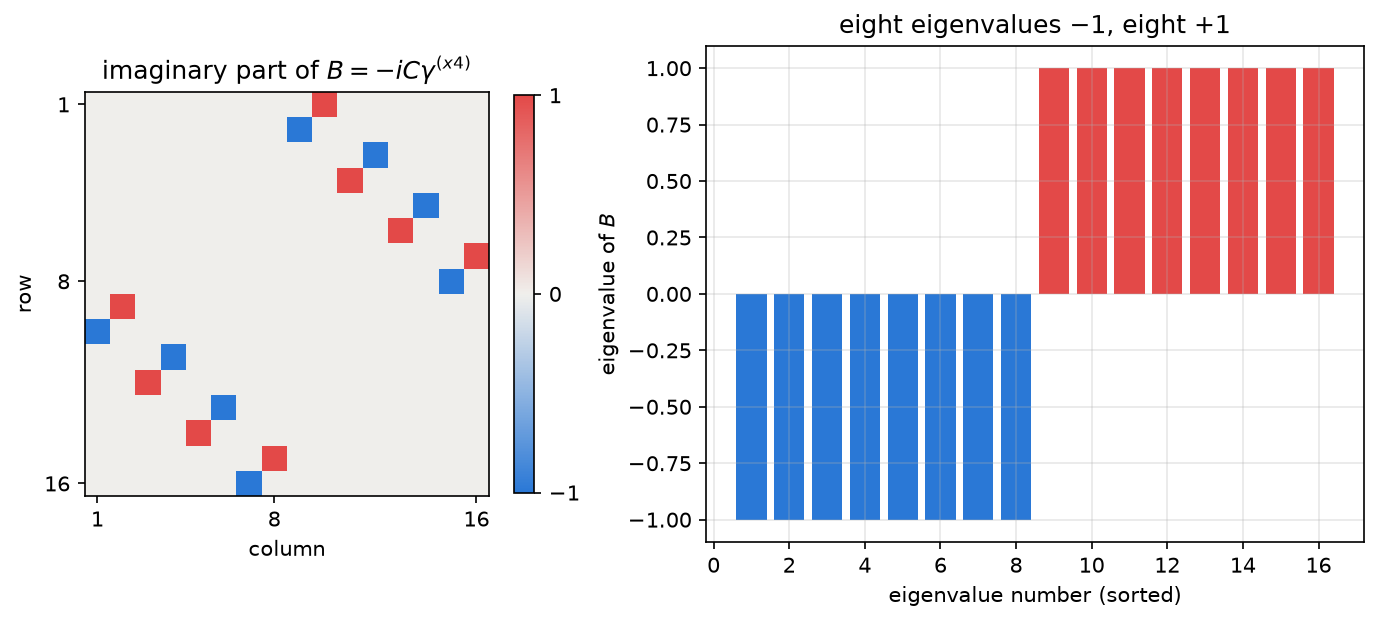

Figure 21c.1 saved as Revision/textbook/figures/21c_1_krein_matrix.png


In [3]:
eigenvalues = np.linalg.eigvalsh(B)  # eigenvalues of a Hermitian matrix, sorted
check(np.array_equal(B.real, np.zeros((16, 16))) and np.allclose(B, B.conj().T)
      and np.allclose(B @ B, np.eye(16)) and abs(np.trace(B)) < 1e-12
      and np.allclose(eigenvalues, [-1] * 8 + [1] * 8)
      and LEAD["B_imaginary_hermitian"] == "PASS"
      and PY_THEORY["B_properties"] == "PASS",
      "B is purely imaginary, Hermitian, B^2 = 1, trace 0: signature (8,8)",
      record=f"{LEAD_FILE}, check B_imaginary_hermitian")
check(np.allclose(B.T, -B), "B^T = -B")

from matplotlib.colors import LinearSegmentedColormap

SIGNS = LinearSegmentedColormap.from_list("signs", ["#2a78d6", "#f0efec", "#e34948"])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3), width_ratios=[1, 1.3])
image = axes[0].imshow(B.imag, cmap=SIGNS, vmin=-1, vmax=1)
axes[0].set_title("imaginary part of $B = -iC\\gamma^{(x4)}$")
axes[0].set_xticks([0, 7, 15], ["1", "8", "16"])
axes[0].set_yticks([0, 7, 15], ["1", "8", "16"])
axes[0].set_xlabel("column")
axes[0].set_ylabel("row")
axes[0].grid(False)
fig.colorbar(image, ax=axes[0], ticks=[-1, 0, 1], shrink=0.8)
axes[1].bar(np.arange(1, 17), eigenvalues,
            color=["#2a78d6"] * 8 + ["#e34948"] * 8)
axes[1].set_xlabel("eigenvalue number (sorted)")
axes[1].set_ylabel("eigenvalue of $B$")
axes[1].set_title("eight eigenvalues $-1$, eight $+1$")
save_figure(fig, "krein_matrix",
            "The Krein matrix $B = -iC\\gamma^{(x4)}$ of the canonical "
            "anticommutator. Left: its imaginary part as a heat map (its real part "
            "is zero; horizontal axis the column, vertical axis the row, red $+1$, "
            "blue $-1$); every row and column has one entry, and the nonzero "
            "entries join the two chiral halves. Right: its sixteen eigenvalues in "
            "increasing order, eight $-1$ and eight $+1$ (signature (8,8)); "
            "because of the eight negative eigenvalues the field adjoint cannot be "
            "an ordinary Hilbert adjoint.")

## 6. Which conjugation keeps the anticommutator?

The next cell computes $MB^TM^\dagger$ for $M = \Gamma$ and $M = 1$ and compares
with the Revision record (check quantum_charge_conjugation_unitary_type). Then it
looks at the whole family $M(t) = \cos t\,1 + \sin t\,\Gamma$ for $t$ from $0$ to
$2\pi$ and computes the size of the mismatch $\|M(t)B^TM(t)^\dagger - B\|$ (the
square root of the sum of the squared moduli of the 256 entries): it vanishes
only at $t = \pi/2$ and $t = 3\pi/2$, where $M = \pm\Gamma$. Finally it checks
that a multiple $c\,\Gamma$ works exactly when $|c| = 1$ (a phase).

PASS M B^T M^dagger = +B for M = Gamma and = -B for M = 1
     reproduces Revision/lead_checks/reports/charge-conjugation-and-u1.json, check
    quantum_charge_conjugation_unitary_type
t where the mismatch vanishes (in units of pi): 0.500, 1.500
PASS in the family cos t + sin t Gamma only t = pi/2, 3pi/2 work; c Gamma works exactly
    for |c| = 1


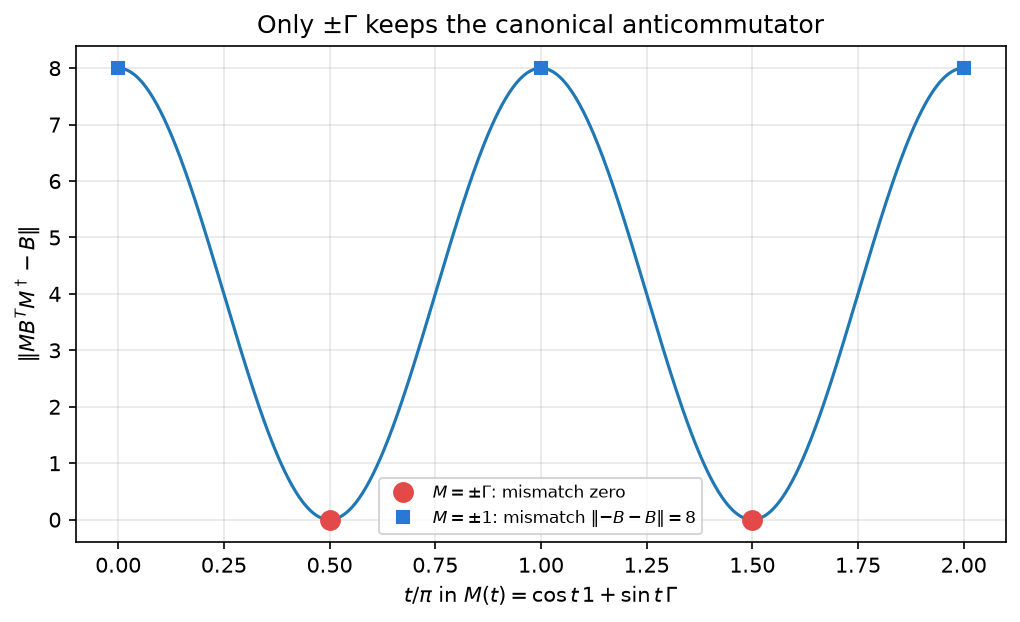

Figure 21c.2 saved as Revision/textbook/figures/21c_2_which_conjugation.png


In [4]:
def mismatch(M):
    """|| M B^T M^dagger - B ||: zero when M keeps the canonical anticommutator."""
    return np.linalg.norm(M @ B.T @ M.conj().T - B)


q_gamma = Gamma @ B.T @ Gamma.T  # M = Gamma (real, so M^dagger = M^T)
q_one = B.T  # M = 1
check(np.allclose(q_gamma, B) and np.allclose(q_one, -B)
      and LEAD["quantum_charge_conjugation_unitary_type"] == "PASS",
      "M B^T M^dagger = +B for M = Gamma and = -B for M = 1",
      record=f"{LEAD_FILE}, check quantum_charge_conjugation_unitary_type")

t_values = np.linspace(0.0, 2 * np.pi, 721)  # steps of half a degree
family = [np.cos(t) * np.eye(16) + np.sin(t) * Gamma for t in t_values]
mismatches = np.array([mismatch(M) for M in family])
zeros = t_values[mismatches < 1e-12]
say("t where the mismatch vanishes (in units of pi): "
    + ", ".join(f"{t / np.pi:.3f}" for t in zeros))
phases_ok = all(abs(mismatch(c * Gamma)) < 1e-12 for c in (1j, np.exp(0.3j), -1))
scales_bad = all(mismatch(c * Gamma) > 1 for c in (0.5, 2.0))
check(np.allclose(zeros / np.pi, [0.5, 1.5]) and phases_ok and scales_bad,
      "in the family cos t + sin t Gamma only t = pi/2, 3pi/2 work; c Gamma works "
      "exactly for |c| = 1")

fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.plot(t_values / np.pi, mismatches)
ax.plot([0.5, 1.5], [0, 0], "o", color="#e34948", markersize=9,
        label="$M = \\pm\\Gamma$: mismatch zero")
ax.plot([0.0, 1.0, 2.0], [mismatch(np.eye(16))] * 3, "s", color="#2a78d6",
        label="$M = \\pm 1$: mismatch $\\|{-B} - B\\| = 8$")
ax.set_xlabel("$t / \\pi$ in $M(t) = \\cos t\\,1 + \\sin t\\,\\Gamma$")
ax.set_ylabel("$\\|M B^T M^\\dagger - B\\|$")
ax.set_title("Only $\\pm\\Gamma$ keeps the canonical anticommutator")
ax.legend(fontsize=8)
save_figure(fig, "which_conjugation",
            "The mismatch $\\|M B^T M^\\dagger - B\\|$ (the size of the failure of "
            "the canonical anticommutator) for the conjugations $\\Psi \\to "
            "M\\Psi^{\\dagger T}$ with $M = \\cos t\\,1 + \\sin t\\,\\Gamma$; "
            "horizontal axis $t/\\pi$ from $0$ to $2$, vertical axis the mismatch "
            "(pure number). It vanishes only at $t = \\pi/2$ and $3\\pi/2$, that is "
            "for $M = \\pm\\Gamma$ (red dots); the same-mass choice $M = \\pm 1$ "
            "(blue squares) gives $-B$ instead of $B$, a mismatch of $\\|2B\\| = 8$.")

## 7. The anticommutators with explicit operators

The next cell builds 16 fermion modes on a computer. A state of the 16 modes is a
column of $2^{16} = 65536$ complex numbers, one for each occupation pattern; the
pattern of basis state number $n$ is the binary digits of $n$ (bit $j$ is the
occupation of mode $j$). The annihilation operator $b_j$ moves the amplitude of
each pattern with bit $j$ set to the pattern with bit $j$ cleared, multiplied by
$(-1)^{(\text{number of occupied modes below } j)}$; the creation operator $b_j^*$
does the reverse. Instead of storing $65536 \times 65536$ matrices, the cell stores
these index lists and applies the operators to columns.

Then the field operators of the positive representation of the Revision record:
$\Psi_A = b_A$ and $\Psi^\dagger_C = \sum_D b_D^*B_{DC}$. Every column of $B$ has
exactly one nonzero entry, so $\Psi^\dagger_C$ is a single creation operator times
$\pm i$. The cell first checks the basic rules $\{b_j, b_k^*\} = \delta_{jk}$ for a
few pairs.

In [5]:
MODES, STATES = 16, 2 ** 16
index = np.arange(STATES)  # basis state numbers 0 .. 65535
occupied_count = np.zeros(STATES, dtype=np.int64)  # number of occupied modes
for j in range(MODES):
    occupied_count += (index >> j) & 1  # >> shifts the bits; & 1 reads bit j
OPS = []  # for each mode j: the states where j is occupied, and the sign factors
for j in range(MODES):
    filled = ((index >> j) & 1).astype(bool)
    below = index & ((1 << j) - 1)  # the bits of the modes below j
    parity = np.zeros(STATES, dtype=np.int64)
    for i in range(j):
        parity += (below >> i) & 1
    OPS.append((index[filled], index[~filled], np.where(parity % 2 == 0, 1.0, -1.0)))


def annihilate(j, v):
    """b_j v: empty mode j (with the Jordan-Wigner sign)."""
    filled, _, sign = OPS[j]
    out = np.zeros_like(v)
    out[filled ^ (1 << j)] = sign[filled] * v[filled]
    return out


def create(j, v):
    """b_j^* v: fill mode j (with the Jordan-Wigner sign)."""
    _, empty, sign = OPS[j]
    out = np.zeros_like(v)
    out[empty | (1 << j)] = sign[empty] * v[empty]
    return out


rng = np.random.default_rng(2103)  # fixed seed: the same state in every run
v = rng.normal(size=STATES) + 1j * rng.normal(size=STATES)
v /= np.linalg.norm(v)  # a random normalised state of the 16 modes
basic = all(np.allclose(annihilate(j, create(k, v)) + create(k, annihilate(j, v)),
                        (1.0 if j == k else 0.0) * v)
            for j, k in [(0, 0), (3, 3), (15, 15), (0, 1), (4, 9), (15, 2)])
check(basic, "Jordan-Wigner operators: {b_j, b_k^*} = delta_jk on a random state")

PASS Jordan-Wigner operators: {b_j, b_k^*} = delta_jk on a random state


The next cell defines the three fields whose anticommutators we compare: the
field $\Psi$ itself, the valid conjugate $\Psi' = \Gamma\Psi^{\dagger T}$ and the
same-mass candidate $\Psi'' = \Psi^{\dagger T}$ ($M = 1$). For each pair $(A, C)$
it applies $\{X, Y\} = XY + YX$ to the random state $v$, reads off the number
$N_{AC} = v^\dagger\{X, Y\}v$, and checks that $\{X, Y\}v = N_{AC}v$ (the
anticommutator acts as a number). It also checks $\{\Psi_A, \Psi_C\} = 0$. (About
10 seconds: 1024 anticommutators of operators on 65536 states.)

In [6]:
B_column = [int(np.flatnonzero(B[:, c])[0]) for c in range(16)]  # row of the entry


def psi(A, u):
    """Psi_A = b_A."""
    return annihilate(A, u)


def psi_dagger(Cc, u):
    """Psi^dagger_C = sum_D b_D^* B_DC (a single term)."""
    D = B_column[Cc]
    return B[D, Cc] * create(D, u)


def field_pair(M):
    """For the conjugate M Psi^{dagger T} with diagonal M: the maps u -> Psi'_A u
    and u -> Psi'^dagger_C u (Psi'_A = M_AA Psi^dagger_A, Psi'^dagger_C =
    conj(M_CC) Psi_C)."""
    d = np.diag(M)
    return (lambda A, u: d[A] * psi_dagger(A, u),
            lambda Cc, u: np.conj(d[Cc]) * psi(Cc, u))


def anticommutator_matrix(first, second):
    """N_AC with {first_A, second_C} v = N_AC v, and whether it acts as a number."""
    N = np.zeros((16, 16), dtype=complex)
    number_like = True
    for A in range(16):
        for Cc in range(16):
            w = first(A, second(Cc, v)) + second(Cc, first(A, v))
            N[A, Cc] = np.vdot(v, w)  # v^dagger w
            number_like &= np.allclose(w, N[A, Cc] * v)
    return N, number_like


N_psi, ok_psi = anticommutator_matrix(psi, psi_dagger)
N_same, ok_same = anticommutator_matrix(psi, psi)  # {Psi_A, Psi_C}
N_gamma, ok_gamma = anticommutator_matrix(*field_pair(Gamma))
N_one, ok_one = anticommutator_matrix(*field_pair(np.eye(16)))
check(ok_psi and ok_same and np.allclose(N_psi, B) and np.allclose(N_same, 0)
      and PY_THEORY["canonical_anticommutator_B"] == "PASS",
      "operators: {Psi_A, Psi^dagger_C} = B_AC and {Psi_A, Psi_C} = 0 (256 pairs)",
      record="Revision/theory/reports/python-field-theory.json, check "
      "canonical_anticommutator_B")
check(ok_gamma and ok_one and np.allclose(N_gamma, B) and np.allclose(N_one, -B),
      "operators: Gamma Psi^{dagger T} has +B, Psi^{dagger T} has -B")

PASS operators: {Psi_A, Psi^dagger_C} = B_AC and {Psi_A, Psi_C} = 0 (256 pairs)
     reproduces Revision/theory/reports/python-field-theory.json, check
    canonical_anticommutator_B
PASS operators: Gamma Psi^{dagger T} has +B, Psi^{dagger T} has -B


The next cell draws the three measured $16 \times 16$ matrices $N_{AC}$ (their
imaginary parts; the real parts are zero).

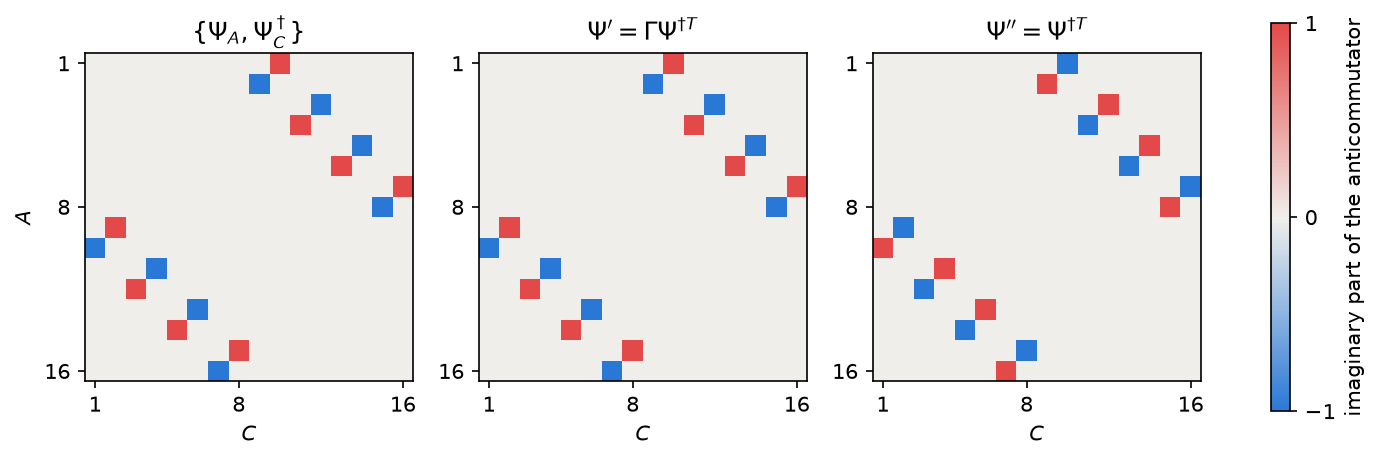

Figure 21c.3 saved as Revision/textbook/figures/21c_3_operator_anticommutators.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.2))
for ax, N, title in ((axes[0], N_psi, "$\\{\\Psi_A, \\Psi^\\dagger_C\\}$"),
                     (axes[1], N_gamma, "$\\Psi' = \\Gamma\\Psi^{\\dagger T}$"),
                     (axes[2], N_one, "$\\Psi'' = \\Psi^{\\dagger T}$")):
    image = ax.imshow(N.imag, cmap=SIGNS, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xticks([0, 7, 15], ["1", "8", "16"])
    ax.set_yticks([0, 7, 15], ["1", "8", "16"])
    ax.set_xlabel("$C$")
    ax.grid(False)
axes[0].set_ylabel("$A$")
fig.colorbar(image, ax=axes, ticks=[-1, 0, 1], shrink=0.8,
             label="imaginary part of the anticommutator")
save_figure(fig, "operator_anticommutators",
            "The anticommutators $\\{X_A, Y^\\dagger_C\\}$ measured with explicit "
            "operators on the 65536 states of 16 fermion modes (imaginary parts; "
            "the real parts are zero; horizontal axis $C$, vertical axis $A$, red "
            "$+1$, blue $-1$). Left: the field $\\Psi$ of the positive "
            "representation, which gives the Krein matrix $B$. Middle: the "
            "conjugate $\\Gamma\\Psi^{\\dagger T}$, which gives $B$ again, so it is "
            "a field of the same quantum theory. Right: the same-mass candidate "
            "$\\Psi^{\\dagger T}$, which gives $-B$ (every colour reversed), so it is "
            "not.")

## 8. The valid conjugation counts the empty modes

The charge operator of the field is $Q = \sum_{A,C}\Psi^\dagger_AB_{AC}\Psi_C$. In
the positive representation $\Psi^\dagger B\Psi = b^*B\,B\,b = b^*b$ (since
$B^2 = 1$): $Q$ is the **number of occupied modes**. For the conjugated field
$\Psi' = \Gamma\Psi^{\dagger T}$, line by line:

1. $Q' = \sum_{A,C}\Psi'^\dagger_AB_{AC}\Psi'_C = \sum_{A,C}\Gamma_{AA}\Gamma_{CC}
   B_{AC}\,\Psi_A\Psi^\dagger_C = \sum_{A,C}(\Gamma B\Gamma)_{AC}\Psi_A
   \Psi^\dagger_C$ ($\Gamma$ is diagonal and real).
2. $\Gamma B\Gamma = -B$, so $Q' = -\sum B_{AC}\Psi_A\Psi^\dagger_C$.
3. The anticommutator gives $\Psi_A\Psi^\dagger_C = B_{AC} - \Psi^\dagger_C
   \Psi_A$, so $Q' = -\sum_{A,C}B_{AC}^2 + \sum_{A,C}\Psi^\dagger_C(B^T)_{CA}
   \Psi_A$.
4. $\sum B_{AC}^2 = \mathrm{tr}(BB^T) = -\mathrm{tr}(B^2) = -16$ and $B^T = -B$,
   so $Q' = 16 - Q$.

The conjugate counts the **empty** modes: up to the constant 16 (which does not
change any difference of charges), it **reverses the charge**, $Q' - 8 = -(Q -
8)$, as particles and holes are exchanged. The same steps with $M = 1$ give
$Q'' = Q - 16$: the invalid candidate would not even reverse the charge. The next
cell checks the three operator identities on the random state and draws the
charges of the 17 kinds of basis states (0 to 16 occupied modes).

PASS Q = number of occupied modes, Q' = 16 - Q (Gamma), Q'' = Q - 16 (M = 1)


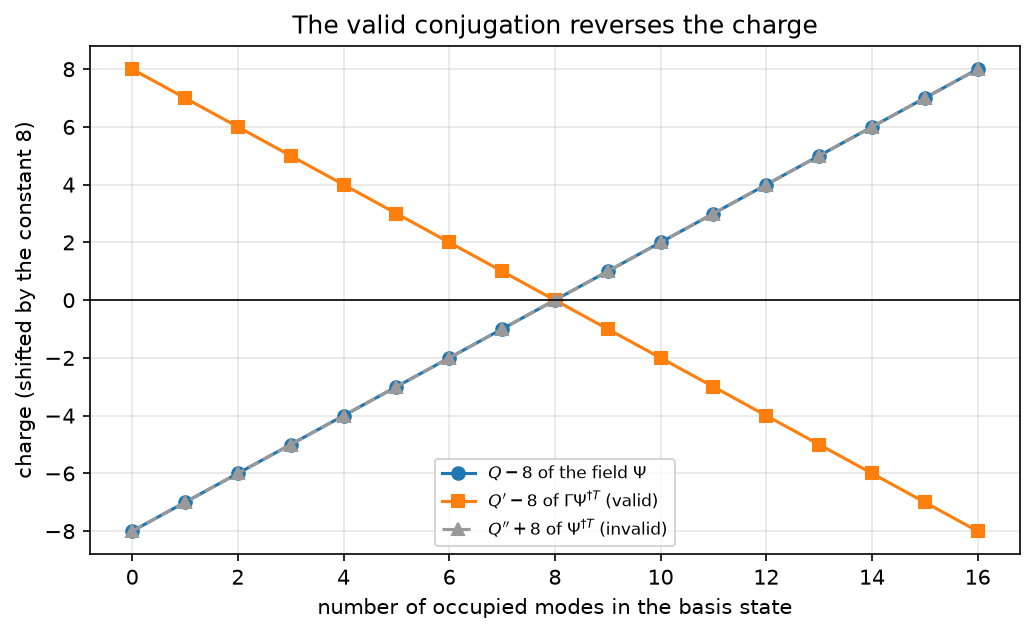

Figure 21c.4 saved as Revision/textbook/figures/21c_4_charge_of_states.png


In [8]:
def charge(first_dagger, second, u):
    """sum_AC first_dagger_A B_AC second_C u (only the 16 nonzero B_AC)."""
    out = np.zeros_like(u)
    for Cc in range(16):
        A = B_column[Cc]  # the row of the nonzero entry of column C
        out += first_dagger(A, B[A, Cc] * second(Cc, u))
    return out


conj_g, conj_g_dagger = field_pair(Gamma)
conj_1, conj_1_dagger = field_pair(np.eye(16))
Q_v = charge(psi_dagger, psi, v)
Qp_v = charge(conj_g_dagger, conj_g, v)
Qpp_v = charge(conj_1_dagger, conj_1, v)
check(np.allclose(Q_v, occupied_count * v)
      and np.allclose(Qp_v, (16 - occupied_count) * v)
      and np.allclose(Qpp_v, (occupied_count - 16) * v),
      "Q = number of occupied modes, Q' = 16 - Q (Gamma), Q'' = Q - 16 (M = 1)")

n = np.arange(17)
fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.plot(n, n - 8, "o-", label="$Q - 8$ of the field $\\Psi$")
ax.plot(n, (16 - n) - 8, "s-", label="$Q' - 8$ of $\\Gamma\\Psi^{\\dagger T}$ "
        "(valid)")
ax.plot(n, (n - 16) + 8, "^--", color="#999999",
        label="$Q'' + 8$ of $\\Psi^{\\dagger T}$ (invalid)")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_xlabel("number of occupied modes in the basis state")
ax.set_ylabel("charge (shifted by the constant 8)")
ax.set_title("The valid conjugation reverses the charge")
ax.legend(fontsize=8)
save_figure(fig, "charge_of_states",
            "The charge of the basis states of 16 fermion modes, measured by three "
            "fields; horizontal axis the number of occupied modes (0 to 16), "
            "vertical axis the charge shifted by the constant 8 (pure numbers). "
            "The field $\\Psi$ counts the occupied modes; the valid conjugate "
            "$\\Gamma\\Psi^{\\dagger T}$ counts the empty ones, $Q' = 16 - Q$, so "
            "the shifted charge is exactly reversed (particles and holes "
            "exchanged); the invalid candidate $\\Psi^{\\dagger T}$ would give "
            "$Q - 16$, not a reversal.")

## 9. The mass is reversed, the spectra are equal

In flat 4+4 space a plane wave $u\,e^{ik\cdot x}$ ($k$ the momenta $k_1, k_2, k_3,
k_5, k_6, k_7, k_8$ along the directions other than the time) evolves by
$i\,\partial_4u = h_m(k)u$ with the one-particle Hamiltonian of the Revision
pairing record
$$h_m(k) = -im\gamma^{(x4)} - \gamma^{(x4)}\sum_{a \ne x4}k_a\gamma^a .$$
The conjugated field contains $\Gamma u^*$: taking the complex conjugate of the
evolution equation gives $i\,\partial_4u^* = -h_m(k)^*u^*$, and multiplying by
$\Gamma$ gives $i\,\partial_4(\Gamma u^*) = -\Gamma h_m(k)^*\Gamma\,(\Gamma u^*)$
(since $\Gamma^2 = 1$). The next cell proves with sympy, for symbolic $m$ and $k$:

1. $-\Gamma h_m(k)^*\Gamma = h_{-m}(-k)$: the conjugated mode is a mode of the
   theory with the **reversed mass** (and the reversed momentum, as $e^{-ik\cdot
   x}$ says);
2. $\Gamma h_m(k)\Gamma = h_{-m}(k)$: the two Hamiltonians are *similar*, so the
   one-particle spectra of the masses $+m$ and $-m$ are **identical**, not opposite
   (record check Q_one_particle_maps);
3. $h_m(k)^2 = w^2\,1$ with $w^2 = m^2 + k_1^2 + k_2^2 + k_3^2 + k_8^2 - k_5^2 -
   k_6^2 - k_7^2$ (record check Q_one_particle_flat_dispersion): the frequencies
   are $\pm w$;
4. $Bh_m = h_m^\dagger B$ for real $m$ and $k$: $h_m$ is self-adjoint for the Krein
   form (Revision check mode_hamiltonian_B_selfadjoint_dispersion).

In [9]:
m = sp.symbols("m", real=True)
k = sp.symbols("k1:9", real=True)  # k[3] (the x4 entry) is not used
G = [sp.Matrix(g.tolist()) for g in gamma]
Gamma_s, B_s = sp.Matrix(Gamma.tolist()), -sp.I * sp.Matrix(C.tolist()) * G[3]


def h(mass, momenta):
    """h_m(k) = -i m gamma^(x4) - gamma^(x4) sum_(a != x4) k_a gamma^a."""
    total = -sp.I * mass * G[3]
    for a in range(8):
        if a != 3:
            total -= momenta[a] * G[3] * G[a]
    return total


zero = sp.zeros(16, 16)
h_m = h(m, k)
minus_k = [-q for q in k]
w2 = m ** 2 + k[0] ** 2 + k[1] ** 2 + k[2] ** 2 + k[7] ** 2 - k[4] ** 2 - k[5] ** 2 \
    - k[6] ** 2
check((-Gamma_s * h_m.conjugate() * Gamma_s - h(-m, minus_k)).expand() == zero,
      "-Gamma conj(h_m(k)) Gamma = h_(-m)(-k): the conjugated mode has the reversed "
      "mass")
check((Gamma_s * h_m * Gamma_s - h(-m, k)).expand() == zero
      and WL_PAIR["Q_one_particle_maps"] == "PASS",
      "Gamma h_m(k) Gamma = h_(-m)(k): equal spectra for +m and -m",
      record="Revision/pairing/reports/wolfram-pairing.json, check "
      "Q_one_particle_maps")
check((h_m * h_m - w2 * sp.eye(16)).expand() == zero
      and (B_s * h_m - h_m.H * B_s).expand() == zero
      and WL_PAIR["Q_one_particle_flat_dispersion"] == "PASS"
      and PY_THEORY["mode_hamiltonian_B_selfadjoint_dispersion"] == "PASS",
      "h_m(k)^2 = w^2 1 and B h_m = h_m^dagger B",
      record="Revision/pairing/reports/wolfram-pairing.json, check "
      "Q_one_particle_flat_dispersion")

PASS -Gamma conj(h_m(k)) Gamma = h_(-m)(-k): the conjugated mode has the reversed mass
PASS Gamma h_m(k) Gamma = h_(-m)(k): equal spectra for +m and -m
     reproduces Revision/pairing/reports/wolfram-pairing.json, check Q_one_particle_maps
PASS h_m(k)^2 = w^2 1 and B h_m = h_m^dagger B
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_one_particle_flat_dispersion


**The eight samples of the pairing record.** For each sample $(m, k)$ of the record
(`Revision/pairing/pairing-theory.json`, data one_particle_flat) the next cell
computes numerically the frequency $w$, the dimensions of the eigenspaces of $+w$
and $-w$, and the **Krein inertia** of each: the numbers of positive and negative
eigenvalues of the matrix $V^\dagger BV$, where the columns of $V$ are an
orthonormal basis of the eigenspace (the eigenspace of $+w$ is the range of the
projector $P_+ = \tfrac12(1 + h_m/w)$). It compares every number with the record
(check Q_one_particle_Krein_signatures).

In [10]:
def numeric_h(mass, momenta):
    """h_m(k) as a numpy array."""
    total = -1j * mass * gamma[3].astype(complex)
    for a in range(8):
        if a != 3:
            total = total - momenta[a] * (gamma[3] @ gamma[a])
    return total


def eigenspace_facts(H_mat, w):
    """Dimension and Krein inertia (positive, negative) of the eigenspace of w."""
    P = (np.eye(16) + H_mat / w) / 2  # projector onto the eigenvalue +w (w != 0)
    U_, s_, _ = np.linalg.svd(P)
    V = U_[:, s_ > 1e-9]  # orthonormal basis of the range of P
    form = np.linalg.eigvalsh(V.conj().T @ B @ V)
    return V.shape[1], (int(np.sum(form > 1e-9)), int(np.sum(form < -1e-9)))


rows_ok = True
for sample in PAIRING["data"]["one_particle_flat"]["samples"]:
    H_mat = numeric_h(sample["m"], sample["k"])
    w = float(sp.sympify(sample["w"].replace("Sqrt[", "sqrt(").replace("]", ")")))
    w_here = np.sqrt(np.max(np.linalg.eigvals(H_mat @ H_mat).real))
    dim_p, inertia_p = eigenspace_facts(H_mat, w_here)
    dim_m, inertia_m = eigenspace_facts(H_mat, -w_here)
    same = (abs(w_here - w) < 1e-12 and dim_p == sample["dim_plus_w"]
            and dim_m == sample["dim_minus_w"]
            and list(inertia_p) == sample["B_inertia_plus_w"]
            and list(inertia_m) == sample["B_inertia_minus_w"])
    rows_ok &= same
    say(f"m = {sample['m']:+d}, k = {sample['k']}: w = {w_here:.6f}, dims "
        f"{dim_p}, {dim_m}, inertia {inertia_p}, {inertia_m}, as recorded: {same}")
check(rows_ok and WL_PAIR["Q_one_particle_Krein_signatures"] == "PASS",
      "all eight one-particle samples of the pairing record reproduced",
      record="Revision/pairing/reports/wolfram-pairing.json, check "
      "Q_one_particle_Krein_signatures")

m = +2, k = [1, 2, 0, 0, 0, 0, 0, 4]: w = 5.000000, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = -2, k = [1, 2, 0, 0, 0, 0, 0, 4]: w = 5.000000, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = +3, k = [0, 0, 0, 0, 0, 0, 0, 0]: w = 3.000000, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = -3, k = [0, 0, 0, 0, 0, 0, 0, 0]: w = 3.000000, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = +1, k = [1, 0, 0, 0, 0, 0, 0, 0]: w = 1.414214, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = -1, k = [1, 0, 0, 0, 0, 0, 0, 0]: w = 1.414214, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = +2, k = [0, 0, 0, 0, 1, 0, 0, 0]: w = 1.732051, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
m = -2, k = [0, 0, 0, 0, 1, 0, 0, 0]: w = 1.732051, dims 8, 8, inertia (4, 4), (4, 4), as
    recorded: True
PASS all eight one-particle samples of the pairing record reproduced
     reproduces Revision/pairing/reports/wolfram-pairing.js

**Scans.** The next cell computes the sixteen eigenvalues of $h_{+m}(k)$ and of
$h_{-m}(k)$ for $m = 1$ along two lines of momenta: along ordinary space ($k_1$
from $-3$ to $3$, all other momenta zero), where $w = \sqrt{1 + k_1^2}$ is real;
and along an extra time ($k_5$ from $-3$ to $3$), where $w^2 = 1 - k_5^2$ becomes
negative for $|k_5| > 1$: the frequencies become imaginary, $\pm i\sqrt{k_5^2 -
1}$, and the modes grow exponentially in time (the ill-posedness of the extra
times). It checks that the spectra of $+m$ and $-m$ agree at every point.

One warning about the two points $k_5 = \pm1$ of the scan. There $w = 0$ and
$h_m^2 = 0$: every eigenvalue is exactly 0, but $h_m$ itself is not the zero
matrix, and such a matrix cannot be brought to diagonal form. For a matrix of this
kind the computer's eigenvalues are accurate only to about the square root of the
rounding unit, about $10^{-8}$, instead of about $10^{-15}$. The function
`spectrum` rounds the eigenvalues to 9 decimals (so that equal values sort in the
same order); the cell compares the two spectra to $10^{-8}$ at all other points
and checks separately that at $k_5 = \pm1$ all 32 computed eigenvalues are
smaller than $10^{-6}$.

PASS scans: identical spectra for m = +1 and m = -1; w = sqrt(1 + k1^2)


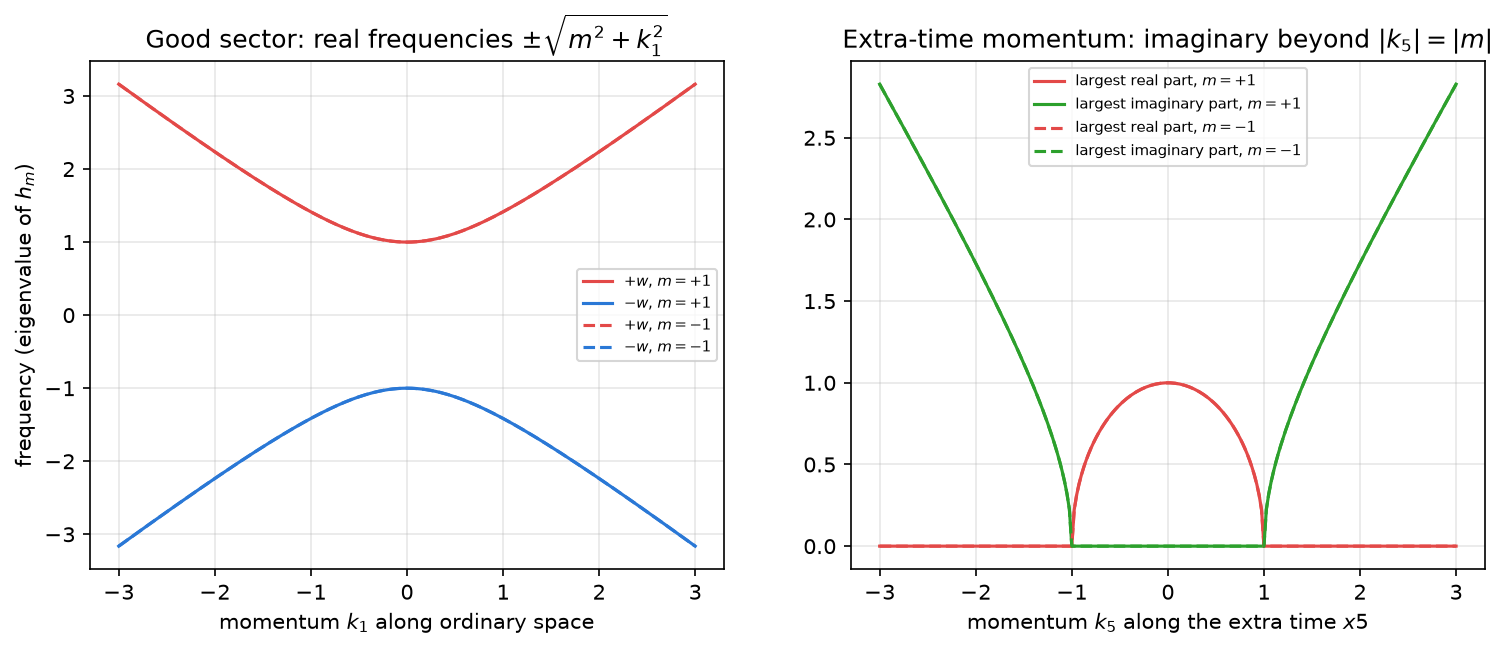

Figure 21c.5 saved as Revision/textbook/figures/21c_5_dispersion_pm_mass.png


In [11]:
def spectrum(mass, k1=0.0, k5=0.0):
    """The 16 eigenvalues of h_m with momenta k1 (x1) and k5 (x5), sorted."""
    momenta = [k1, 0, 0, 0, k5, 0, 0, 0]
    values = np.linalg.eigvals(numeric_h(mass, momenta))
    return np.sort_complex(np.round(values, 9))


scan = np.linspace(-3.0, 3.0, 241)  # steps of 0.025; contains k5 = -1 and +1
spec_k1 = {s: np.array([spectrum(s, k1=q) for q in scan]) for s in (1, -1)}
spec_k5 = {s: np.array([spectrum(s, k5=q) for q in scan]) for s in (1, -1)}
exceptional = np.abs(np.abs(scan) - 1.0) < 1e-9  # the two points k5 = -1, +1
check(np.allclose(spec_k1[1], spec_k1[-1], rtol=0, atol=1e-8)
      and np.allclose(spec_k5[1][~exceptional], spec_k5[-1][~exceptional],
                      rtol=0, atol=1e-8)
      and np.abs(spec_k5[1][exceptional]).max() < 1e-6
      and np.abs(spec_k5[-1][exceptional]).max() < 1e-6
      and np.allclose(np.abs(spec_k1[1].real).max(axis=1), np.sqrt(1 + scan ** 2)),
      "scans: identical spectra for m = +1 and m = -1; w = sqrt(1 + k1^2)")

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
for s, style, label in ((1, "-", "$m = +1$"), (-1, "--", "$m = -1$")):
    axes[0].plot(scan, spec_k1[s].real.max(axis=1), style, color="#e34948",
                 label=f"$+w$, {label}")
    axes[0].plot(scan, spec_k1[s].real.min(axis=1), style, color="#2a78d6",
                 label=f"$-w$, {label}")
    axes[1].plot(scan, spec_k5[s].real.max(axis=1), style, color="#e34948",
                 label=f"largest real part, {label}")
    axes[1].plot(scan, spec_k5[s].imag.max(axis=1), style, color="#2ca02c",
                 label=f"largest imaginary part, {label}")
axes[0].set_xlabel("momentum $k_1$ along ordinary space")
axes[0].set_ylabel("frequency (eigenvalue of $h_m$)")
axes[0].set_title("Good sector: real frequencies $\\pm\\sqrt{m^2 + k_1^2}$")
axes[0].legend(fontsize=7)
axes[1].set_xlabel("momentum $k_5$ along the extra time $x5$")
axes[1].set_title("Extra-time momentum: imaginary beyond $|k_5| = |m|$")
axes[1].legend(fontsize=7)
save_figure(fig, "dispersion_pm_mass",
            "One-particle frequencies of the flat 4+4 Hamiltonian $h_m(k)$ for "
            "$m = +1$ (solid) and $m = -1$ (dashed, on top of the solid lines). "
            "Left: versus the momentum $k_1$ along ordinary space; the frequencies "
            "$\\pm\\sqrt{1 + k_1^2}$ are real and the same for both masses. Right: "
            "versus the momentum $k_5$ along an extra time; for $|k_5| < 1$ the "
            "largest real part is $\\sqrt{1 - k_5^2}$, for $|k_5| > 1$ the "
            "frequencies are imaginary, $\\pm i\\sqrt{k_5^2 - 1}$ (green), and the "
            "modes grow in time. Horizontal axes the momentum, vertical axes the "
            "frequency (pure numbers, units with $m = 1$).")

**Krein inertia along the extra-time scan.** For every real frequency the
eigenspace of $+w$ has dimension 8 and Krein inertia (4,4): the form
$u^\dagger Bu$ takes both signs on it. For an imaginary frequency the record
proves that the eigenspace is **Krein-neutral**: from $Bh = h^\dagger B$,
$w\,u^\dagger Bv = u^\dagger Bhv = (hu)^\dagger Bv = w^*u^\dagger Bv$, so
$(w - w^*)u^\dagger Bv = 0$ and the form vanishes when $w$ is not real. The next
cell computes the inertia of the eigenspace of the eigenvalue with the largest
real part (or, beyond $|k_5| = 1$, the largest imaginary part) along the $k_5$
scan and checks both statements (record check
Q_one_particle_complex_and_zero_frequencies_Krein_neutral).

PASS inertia (4,4) at real frequencies, Krein-neutral at imaginary frequencies
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    Q_one_particle_complex_and_zero_frequencies_Krein_neutral


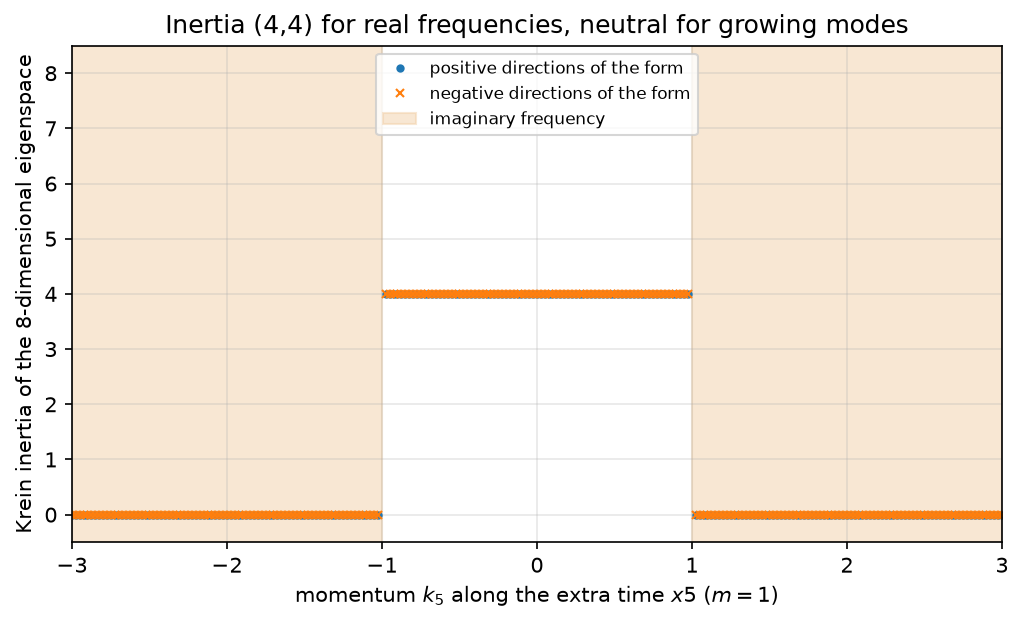

Figure 21c.6 saved as Revision/textbook/figures/21c_6_krein_inertia_scan.png


In [12]:
def leading_inertia(k5):
    """Dimension and Krein inertia of the eigenspace of the leading eigenvalue."""
    H_mat = numeric_h(1, [0, 0, 0, 0, k5, 0, 0, 0])
    w2_here = 1 - k5 ** 2
    w = np.sqrt(w2_here) if w2_here > 0 else 1j * np.sqrt(-w2_here)
    return eigenspace_facts(H_mat, w)


k5_scan = scan[np.abs(np.abs(scan) - 1.0) > 1e-6]  # leave out w = 0 at |k5| = 1
facts = [leading_inertia(q) for q in k5_scan]
positive = np.array([f[1][0] for f in facts])
negative = np.array([f[1][1] for f in facts])
dims = np.array([f[0] for f in facts])
real_region = np.abs(k5_scan) < 1
check(np.all(dims == 8)
      and np.all(positive[real_region] == 4) and np.all(negative[real_region] == 4)
      and np.all(positive[~real_region] == 0) and np.all(negative[~real_region] == 0)
      and WL_PAIR["Q_one_particle_complex_and_zero_frequencies_Krein_neutral"]
      == "PASS",
      "inertia (4,4) at real frequencies, Krein-neutral at imaginary frequencies",
      record="Revision/pairing/reports/wolfram-pairing.json, check "
      "Q_one_particle_complex_and_zero_frequencies_Krein_neutral")

fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.plot(k5_scan, positive, "o", markersize=3, label="positive directions of the form")
ax.plot(k5_scan, negative, "x", markersize=4, label="negative directions of the form")
ax.axvspan(-3, -1, color="#f2d0a9", alpha=0.5, label="imaginary frequency")
ax.axvspan(1, 3, color="#f2d0a9", alpha=0.5)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.5, 8.5)
ax.set_xlabel("momentum $k_5$ along the extra time $x5$ ($m = 1$)")
ax.set_ylabel("Krein inertia of the 8-dimensional eigenspace")
ax.set_title("Inertia (4,4) for real frequencies, neutral for growing modes")
ax.legend(fontsize=8, loc="upper center")
save_figure(fig, "krein_inertia_scan",
            "The Krein inertia of the 8-dimensional eigenspace of the leading "
            "eigenvalue of $h_m(k)$, $m = 1$, along the momentum $k_5$ of an extra "
            "time: the numbers of positive (circles) and negative (crosses) "
            "eigenvalues of the form $u^\\dagger Bu$ restricted to it; horizontal "
            "axis $k_5$, vertical axis the counts. For $|k_5| < 1$ (real "
            "frequency) the inertia is (4,4); in the shaded regions $|k_5| > 1$ the "
            "frequency is imaginary, the mode grows, and the form vanishes on the "
            "whole eigenspace (Krein-neutral).")

## 10. The figure files

The last cell checks that the six figure files exist and prints the number of
checks that passed.

In [13]:
names = sorted(FIGURE_NUMBERS, key=FIGURE_NUMBERS.get)
check(len(names) == 6 and all(
    output_file(f"{FIGURE_FOLDER}/21c_{FIGURE_NUMBERS[n]}_{n}.png").is_file()
    for n in names), "the six figure files of notebook 21c exist")
all_checks_passed()

PASS the six figure files of notebook 21c exist
ALL 16 CHECKS PASSED (notebook 21c)


## 11. What this notebook showed

- PROVED (exact matrix algebra, reproducing the Revision record): a conjugation
  $\Psi \to M\Psi^{\dagger T}$ of the quantised field keeps the canonical
  anticommutator $\{\Psi, \Psi^\dagger\} = B\,\delta$ if and only if
  $MB^TM^\dagger = B$; this holds for $M = \Gamma$ (times a phase) and fails for
  $M = 1$, which gives $-B$. Among $\cos t\,1 + \sin t\,\Gamma$ only $\pm\Gamma$
  works.
- COMPUTED (explicit operators on the 65536 states of 16 fermion modes, in the
  positive representation of the Revision record): all 256 anticommutators of
  $\Psi$, of $\Gamma\Psi^{\dagger T}$ and of $\Psi^{\dagger T}$ act as the numbers
  $B$, $B$ and $-B$.
- PROVED: the valid conjugation counts the empty modes, $Q' = 16 - Q$: up to a
  constant it reverses the charge (particles and holes exchanged).
- PROVED (sympy, symbolic $m$ and $k$): the conjugated field evolves with the
  **reversed mass**, $-\Gamma h_m(k)^*\Gamma = h_{-m}(-k)$; at the same time
  $\Gamma h_m\Gamma = h_{-m}$, so the one-particle spectra of $+m$ and $-m$ are
  identical, not opposite.
- Reproduced: the eight one-particle samples of the pairing record; Krein inertia
  (4,4) at every real frequency of the scan; Krein-neutral eigenspaces for the
  growing extra-time modes.
- Consequence: for the quantised field dirac16complex the conjugation that is
  compatible with canonical quantisation is $\Psi \to \Gamma\Psi^{\dagger T}$,
  which maps the theory with mass $m$ to the theory with mass $-m$; the same-mass
  candidate is not compatible. This is a statement about the anticommutator and
  the field equation; no regularised quantum field theory in signature (4,4) is
  constructed here, and nothing in it creates particles, antiparticles or
  universes.